# GPT-2 Small Greater than Capability Analysis

Here we perform the initial interpretability work on GPT-2 Small through ablation experiments, logit extractions, attention head visualizations, and other methods. The goal will be to build a circuit map by tracing important attention heads and MLP layers.

In [9]:
# Set project root
import sys
sys.path.append("/Users/benjawesome/coding/greater-than-cap-analysis")

In [10]:
# Imports and device....

import torch

device = torch.device('mps')

In [11]:
# More imports...

# Transformer lens and GPT2-Small
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gpt2-small", device=device)

# Import our prompt generation script and create 50 prompts
from data.greater_than_prompt_generation import generate_dataset
from data.greater_than_prompt_generation import generate_full_dataset

prompts_50 = generate_dataset(50)
all_prompts = generate_full_dataset()

import matplotlib.pyplot as plt

Loaded pretrained model gpt2-small into HookedTransformer


In [5]:
# Loop through the prompts and check accuracy

correct = 0
count = 0

for pair in all_prompts:
    # Extract prompt and number
    prompt = pair[0]
    num = pair[1]

    # Tokenize and extract logits
    tokens = model.to_tokens(prompt)
    logits = model(tokens)

    # Print model's prediction
    prediction = model.to_string(logits[0, -1, :].argmax(dim=-1))
    prediction = int(prediction)

    # Log accuracy
    if (prediction > num):
        correct += 1

    count += 1

print("The model correctly predicted " + str(correct) + " out of " + str(count) + " prompts.")

The model correctly predicted 94 out of 99 prompts.


## Logit Lens and Attention Pattern extraction

Here we extract and plot the logit lenses of all 12 layers for three select prompts. We will extract the residual stream after each layer and then project it into the vocabulary space, plotting the model's predictions at each layer to see how predictions develop.

In [ ]:
# Create prompts and run them through the model

prompts = generate_dataset(3)

prompt1 = prompts[0][0]
prompt2 = prompts[1][0]
prompt3 = prompts[2][0]


_, cache1 = model.run_with_cache(prompt1)
_, cache2 = model.run_with_cache(prompt2)
_, cache3 = model.run_with_cache(prompt3)

for prompt in prompts:
    print(model.generate(prompt[0], 1) + "\n")

100%|██████████| 1/1 [00:00<00:00, 27.51it/s]


The war lasted from 1842 to 1848



100%|██████████| 1/1 [00:00<00:00, 78.92it/s]


The war lasted from 1837 to 1839



100%|██████████| 1/1 [00:00<00:00, 68.72it/s]

The war lasted from 1815 to 1850



In [ ]:
# Extract attention patterns and visualize them with matplotlib

import math

attention_patterns = {
    "prompt1": [cache1["pattern", layer][0].detach().cpu() for layer in range(model.cfg.n_layers)],
    "prompt2": [cache2["pattern", layer][0].detach().cpu() for layer in range(model.cfg.n_layers)],
    "prompt3": [cache3["pattern", layer][0].detach().cpu() for layer in range(model.cfg.n_layers)],
}

def plot_attention_patterns(cache, prompt, prompt_label):
    tokens = model.to_str_tokens(prompt)
    n_heads = model.cfg.n_heads
    n_cols = 4
    n_rows = math.ceil(n_heads / n_cols)

    for layer in range(model.cfg.n_layers):
        pattern = cache["pattern", layer][0].detach().cpu()
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
        axes = axes.flatten()

        for head in range(n_heads):
            ax = axes[head]
            im = ax.imshow(pattern[head], cmap="viridis", vmin=0, vmax=pattern[head].max().item())
            ax.set_title(f"Head {head}")
            ax.set_xticks(range(len(tokens)))
            ax.set_yticks(range(len(tokens)))
            ax.set_xticklabels(tokens, rotation=90)
            ax.set_yticklabels(tokens)

        for ax in axes[n_heads:]:
            ax.axis("off")

        fig.suptitle(f"{prompt_label} | Layer {layer} attention patterns", fontsize=16)
        fig.colorbar(im, ax=axes.tolist(), shrink=0.7)
        plt.tight_layout()
        plt.show()

plot_attention_patterns(cache1, prompt1, "Prompt 1")
plot_attention_patterns(cache2, prompt2, "Prompt 2")
plot_attention_patterns(cache3, prompt3, "Prompt 3")


In [12]:
# Extract the IDs of all of the numbers 01 to 99
candidate_labels = []
token_ids = []

for i in range(1, 100):
    num = f"{i:02d}"
    candidate_labels.append(num)

    # We want a clean vocab index for each two-digit completion.
    token_id = model.to_tokens(num, prepend_bos=False).squeeze(0)
    if token_id.numel() != 1:
        raise ValueError(f"{num} does not map to a single GPT-2 token.")

    token_ids.append(int(token_id.item()))

token_id_tensor = torch.tensor(token_ids, device=model.cfg.device)

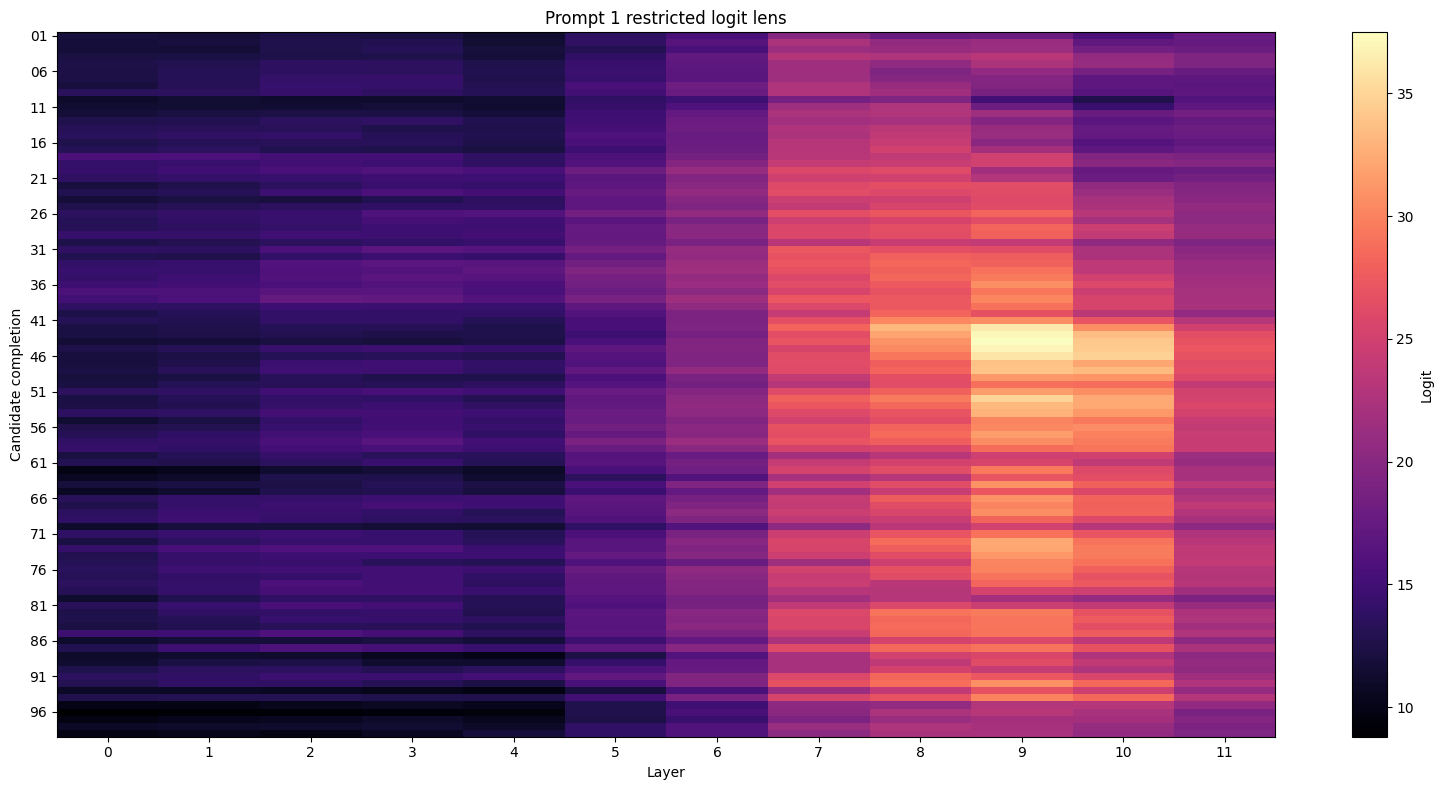

The war lasted from 1842 to 18
Top candidate per layer:
['37', '37', '38', '38', '34', '34', '38', '42', '42', '44', '46', '45']


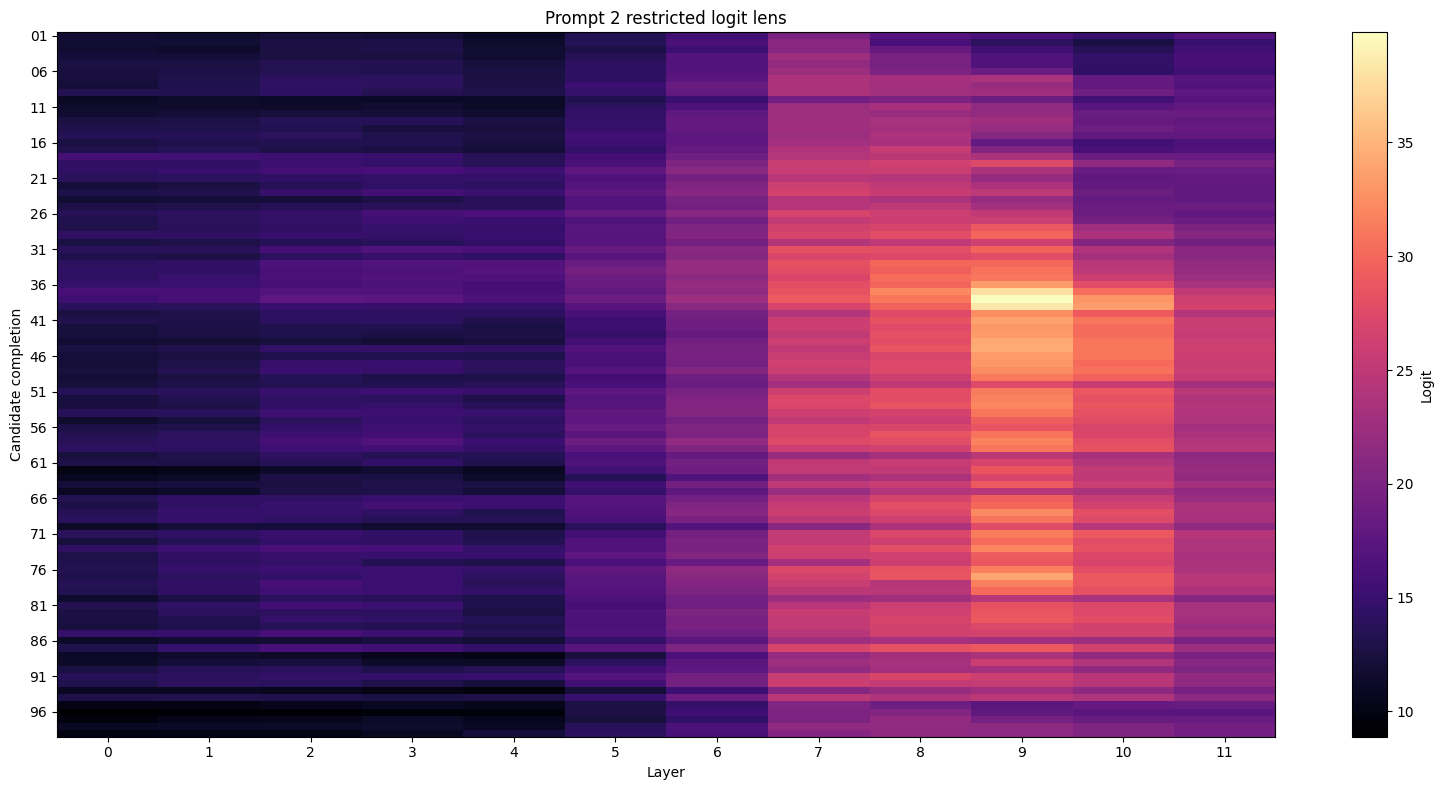

The war lasted from 1837 to 18
Top candidate per layer:
['37', '37', '38', '38', '34', '34', '38', '38', '37', '38', '39', '39']


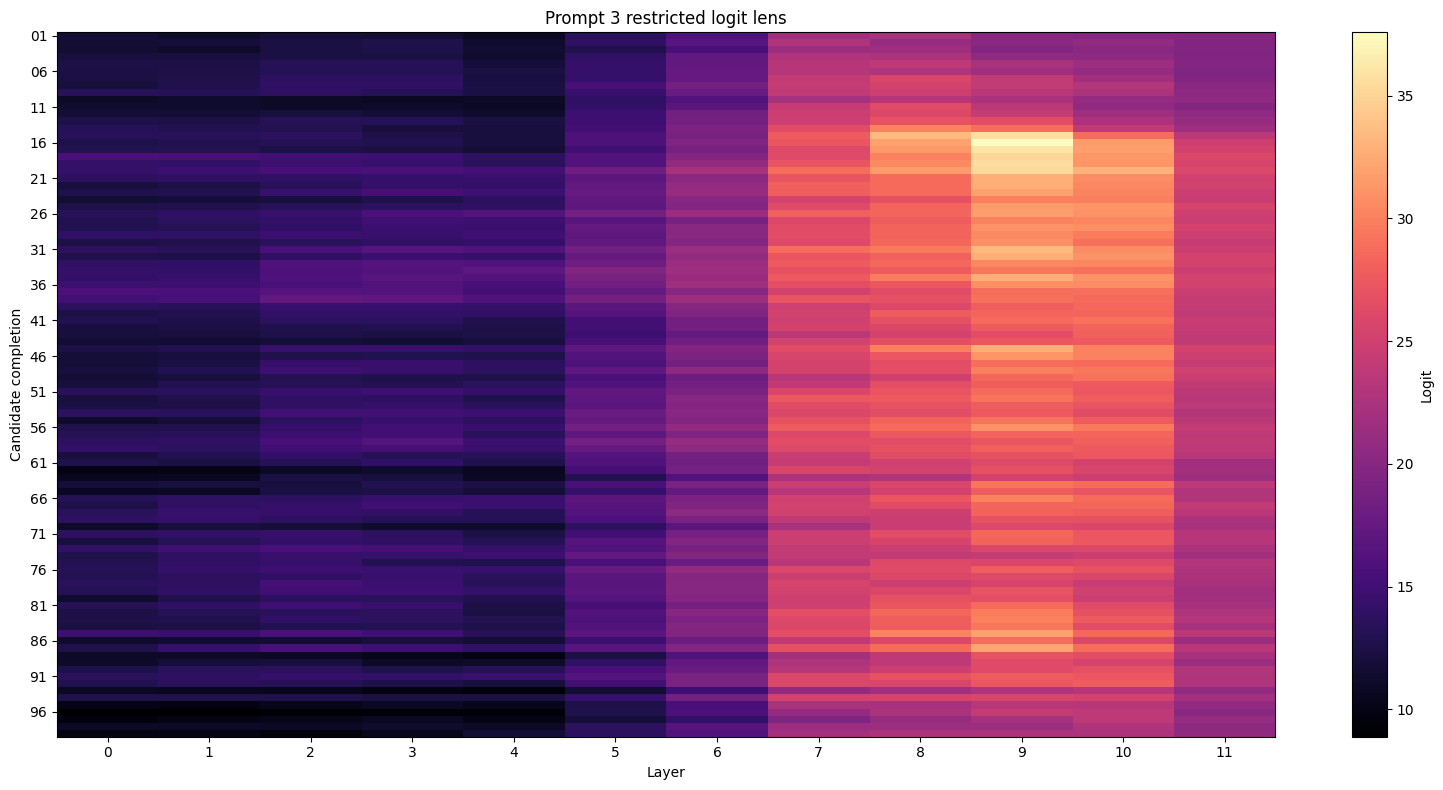

The war lasted from 1815 to 18
Top candidate per layer:
['37', '37', '38', '38', '34', '34', '20', '20', '15', '16', '20', '20']


In [15]:
# Project each layer's residual stream through GPT-2's final unembedding matrix

def compute_restricted_logit_lens(cache):
    layer_logits = []

    for layer in range(model.cfg.n_layers):
        resid_post = cache["resid_post", layer][:, -1, :]

        # A proper logit lens applies ln_final before the unembedding projection.
        normalized_resid = model.ln_final(resid_post)
        logits = normalized_resid @ model.W_U[:, token_id_tensor]

        if model.b_U is not None:
            logits = logits + model.b_U[token_id_tensor]

        layer_logits.append(logits.squeeze(0).detach().cpu())

    return torch.stack(layer_logits)

logit_lens1 = compute_restricted_logit_lens(cache1)
logit_lens2 = compute_restricted_logit_lens(cache2)
logit_lens3 = compute_restricted_logit_lens(cache3)

def plot_restricted_logit_lens(logit_lens, prompt, prompt_label):
    fig, ax = plt.subplots(figsize=(16, 8))
    im = ax.imshow(logit_lens.T, aspect="auto", cmap="magma")

    ax.set_title(f"{prompt_label} restricted logit lens")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Candidate completion")
    ax.set_xticks(range(model.cfg.n_layers))

    y_ticks = list(range(0, len(candidate_labels), 5))
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([candidate_labels[i] for i in y_ticks])

    target_suffix = prompt[-2:]

    fig.colorbar(im, ax=ax, label="Logit")
    plt.tight_layout()
    plt.show()

    top_candidates = logit_lens.argmax(dim=-1).tolist()
    print(prompt)
    print("Top candidate per layer:")
    print([candidate_labels[idx] for idx in top_candidates])

plot_restricted_logit_lens(logit_lens1, prompt1, "Prompt 1")
plot_restricted_logit_lens(logit_lens2, prompt2, "Prompt 2")
plot_restricted_logit_lens(logit_lens3, prompt3, "Prompt 3")

Text(0.5, 1.0, 'Layer 5')

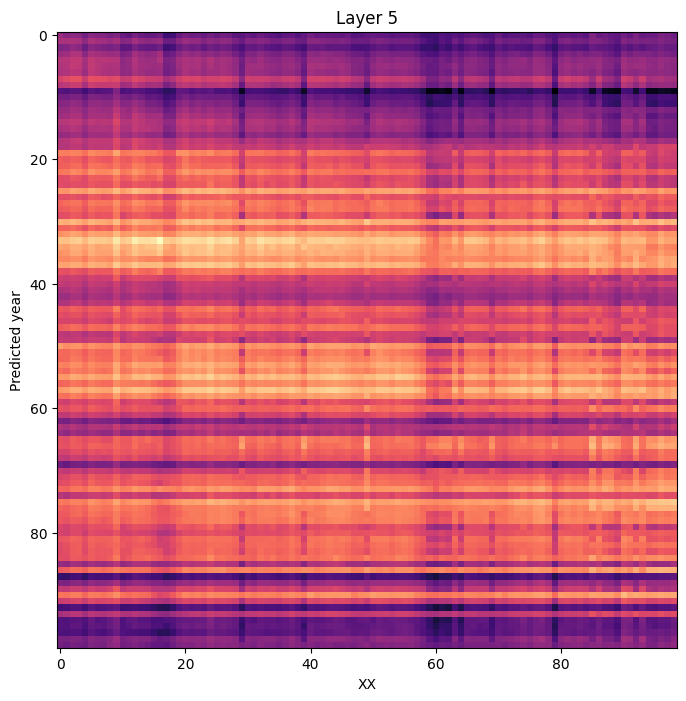

In [20]:
# Now we plot the logit lens for all of the prompts at once

logit_lenses = []
layer = 5

for i in range(1, 100):
    # Create prompt
    num = f"{i:02d}"
    prompt = "The war lasted from 18" + num + " to 18"

    _, cache = model.run_with_cache(prompt)

    # Extract residual stream post attention layer & compute logits
    resid_post = cache["resid_post", layer][:, -1, :]
    normalized_resid = model.ln_final(resid_post)
    logits = normalized_resid @ model.W_U[:, token_id_tensor]

    # Append logits
    logit_lenses.append(logits.squeeze(0).detach().cpu())

logit_lenses = torch.stack(logit_lenses)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(logit_lenses.T, aspect="auto", cmap="magma")

plt.xlabel("XX")
plt.ylabel("Predicted year")
plt.title("Layer " + str(layer))

# Ablations

In the following cell we try two different kinds of ablations: ablating every single attention head independently, and layer by layer complete ablation.

In [20]:
# Loop through every attention head and ablate (zero) to measure change in accuracy

accuracies = []

def calculate_ablated_accuracy(prompts, layer_to_ablate, head_index_to_ablate):
    # Initialize
    correct = 0
    count = 0

    def head_ablation_hook(value, hook):
        # value[:, :, head_index_to_ablate, :] = 0
        value[:, :, :, :] = 0
        return value

    for pair in prompts:
        # Extract prompt and number
        prompt = pair[0]
        num = pair[1]

        # Tokenize and extract logits
        tokens = model.to_tokens(prompt)
        
        logits = model.run_with_hooks(tokens, return_type='logits', 
                        fwd_hooks=[(
                            f"blocks.{layer_to_ablate}.attn.hook_z", # Need to set hook point @ attention output
                            head_ablation_hook
                        )])
        
        # Get model prediction
        prediction = logits[0, -1].argmax()
        try:
            prediction = int(model.to_string(prediction))
            if prediction > num:
                correct += 1
        except ValueError:
            pass 

        count += 1

    return count, correct

for layer in range(model.cfg.n_layers):
    # for head in range(model.cfg.n_heads):
    count, correct = calculate_ablated_accuracy(all_prompts, layer, head)
    print("Layer " + str(layer) + " attention head " + str(head) + " accuracies: " + str(correct))

Layer 0 attention head 4 accuracies: 75
Layer 1 attention head 4 accuracies: 94
Layer 2 attention head 4 accuracies: 93
Layer 3 attention head 4 accuracies: 93
Layer 4 attention head 4 accuracies: 93
Layer 5 attention head 4 accuracies: 93
Layer 6 attention head 4 accuracies: 93
Layer 7 attention head 4 accuracies: 93
Layer 8 attention head 4 accuracies: 93
Layer 9 attention head 4 accuracies: 91
Layer 10 attention head 4 accuracies: 93
Layer 11 attention head 4 accuracies: 94


### Attention Ablations

The individual head ablation tests yielded that ablating layer 0 head 9 and layer 9 head 1 both lead to significant decrease in model prediction accuracy (94 -> 90). The rest of the drops in accuracies are largely insignificant across isolated attention heads (94 -> 93 in invidual heads).

When ablating attention outputs across a layer entirely we see that layer 9's attention outputs play an important role in the greater than circuit (94 -> 91). Furthermore, ablating layer 0 leads to a huge drop in accuracy (94 -> 75), which I suspect is due to layer 0 processing basic information like attending to the previous token, first token, last token, etc.

In [7]:
# Try grouping together attention heads and then ablating them together to measure change in performance
    
# Initialize (try ablating heads which lead to drop in performance)
head_combinations = [(False, True, False, False, False, False, True, False, False, False, False, False),
                     (False, False, False, False, False, False, True, False, False, False, False, False),
                     (False, True, False, False, False, False, False, False, False, False, False, False),
                     (True, False, True, True, True, True, True, True, True, True, True, True)
                     ]
all_prompts = generate_full_dataset()

def ablate_combinations(prompts, layer_to_ablate, head_combinations):
    """
        Ablates groups of heads as defined in head_combinations and records
        the result in a dictionary.
    """
    accuracies = {}
    for combination in head_combinations:
        # Initialize
        correct = 0

        # Define our ablation hook function
        def head_ablation_hook(value, hook):
            # Loop through the combination and ablate indicated heads (false = ablate, true = normal)
            for i in range(len(combination)):
                if (combination[i]):
                    value[:, :, i, :] = 0
        
        for pair in prompts:
            # Extract prompt and number
            prompt = pair[0]
            num = pair[1]
            
            # Extract tokens and logits
            tokens = model.to_tokens(prompt)
            logits = model.run_with_hooks(tokens, return_type='logits',
                                        fwd_hooks=[(
                                        f"blocks.{layer_to_ablate}.attn.hook_z",
                                        head_ablation_hook
                                        )])
            prediction = logits[0, -1].argmax()
            try:
                prediction = int(model.to_string(prediction))
                if prediction > num:
                    correct += 1
            except ValueError:
                pass 
        
        # Add this combination and it's accuracy to the dictionary
        accuracies[combination] = correct
    
    # Return the dictionary of accuracies
    return accuracies

accuracies = ablate_combinations(all_prompts, 9, head_combinations)

# Sort dictionary
sorted_accuracies = dict(sorted(accuracies.items(), key=lambda item: item[1]))

for key, val in list(sorted_accuracies.items()):
    print(key, val)

(False, True, False, False, False, False, False, False, False, False, False, False) 90
(False, True, False, False, False, False, True, False, False, False, False, False) 91
(False, False, False, False, False, False, True, False, False, False, False, False) 93
(True, False, True, True, True, True, True, True, True, True, True, True) 94


In [47]:
# Now we inspect the MLPs to probe further

accuracies = {}

for layer in range(model.cfg.n_layers):
    correct = 0
    # Define hook point
    def mlp_ablation_hook(value, hook):
        value[:, :, :] = 0
        return value
    
    for pair in all_prompts:
        prompt = pair[0]
        num = pair[1]
            
        # Extract tokens and logits
        tokens = model.to_tokens(prompt)
        logits = model.run_with_hooks(tokens, return_type='logits',
                                    fwd_hooks=[(
                                    f"blocks.{layer}.hook_mlp_out",
                                    mlp_ablation_hook
                                    )])
        prediction = logits[0, -1].argmax()
        try:
            prediction = int(model.to_string(prediction))
            if prediction > num:
                correct += 1
        except ValueError:
            pass     
    accuracies[layer] = correct

# Print
for key, val in list(accuracies.items()):
    print("Layer " + str(key) + " MLP ablation accuracy " + str(val))

Layer 0 MLP ablation accuracy 75
Layer 1 MLP ablation accuracy 93
Layer 2 MLP ablation accuracy 93
Layer 3 MLP ablation accuracy 93
Layer 4 MLP ablation accuracy 94
Layer 5 MLP ablation accuracy 93
Layer 6 MLP ablation accuracy 94
Layer 7 MLP ablation accuracy 95
Layer 8 MLP ablation accuracy 94
Layer 9 MLP ablation accuracy 68
Layer 10 MLP ablation accuracy 82
Layer 11 MLP ablation accuracy 94


In [48]:
"""
    At this point, we notice that the circuit must be heavily MLP dependent
    via our ablation tests. In particular, MLPs 9 and 10 are central to the
    greater than circuit, and so is attention layer 9 (likely has to
    do with the fact that the output of the layer 9 attention heads is what
    feeds into MLP 9). Curiosuly, our logit lens depicts diagonal structure emerging
    around layers 7 to 8, which is surprising since the ablation test revealed
    no significant drop in accuracy in those layers. Here we test if the outputs of 
    those layers ablated combined with MLP 9 ablated lead to greater loss in accuracy.
"""

def head_ablation_hook(value, hook):
    value[:, :, :, :] = 0
    return value

def mlp_ablation_hook(value, hook):
    value[:, :, :] = 0
    return value

# Initialize
correct = 0

for pair in all_prompts:
    # Extract fields
    prompt = pair[0]
    num = pair[1]

    # Extract tokens and logits
    tokens = model.to_tokens(prompt)
    logits = model.run_with_hooks(tokens, return_type='logits', 
                                fwd_hooks=[
                                #(f"blocks.7.attn.hook_z",
                                #head_ablation_hook),
                                (f"blocks.5.attn.hook_z",
                                head_ablation_hook),
                                (f"blocks.9.hook_mlp_out",
                                mlp_ablation_hook)
                                ])
    
    prediction = logits[0, -1].argmax()

    try:
        prediction = int(model.to_string(prediction))
        if prediction > num:
            correct += 1
    except ValueError:
        pass 

print(correct)

56


### MLP + Attention Ablations

The results of the cell above:
- All three ablated: 40 correct out of 99
- Attention layer 5 and MLP 9 ablated: 56 correct out of 99
- Attention layer 7 and MLP 9 ablated: 62 correct out of 99
- Attention layer 8 and MLP 9 ablated: 56 correct out of 99

The baseline accuracies are:
- MLP 9 ablated: 68 correct out of 99
- Attention layer 5 ablated: 93 corect out of 99
- Attention layer 7 ablated: 93 correct out of 99
- Attention layer 8 ablated: 93 correct out of 99